# **Product Recognition of Books**

## Image Processing and Computer Vision - Assignment Module \#1

Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it


Computer vision-based object detection techniques can be applied in library or bookstore settings to build a system that identifies books on shelves.

Such a system could assist in:

- Helping visually impaired users locate books by title/author;
- Automating inventory management (e.g., detecting misplaced or out-of-stock books);
- Enabling faster book retrieval by recognizing spine text or cover designs.


## Data

Two folders of images are provided:

- **Models**: contains one reference image for each product that the system should be able to identify;
- **Scenes**: contains different shelve pictures to test the developed algorithm in different scenarios.


In [171]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp -r /content/drive/MyDrive/dataset_ipcv/dataset.zip ./
# !unzip dataset.zip

In [172]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

# Set latex font for plots cmu
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["font.size"] = 16

In [173]:
MODELS_FOLDER = "./dataset/models"
SCENES_FOLDER = "./dataset/scenes"

# read all the images inside all models and scene
models_images = []
scenes_images = []

for folder, image_list, image_name, image_ext in [
    (MODELS_FOLDER, models_images, "model", "png"),
    (SCENES_FOLDER, scenes_images, "scene", "jpg"),
]:
    num_images = len(
        [name for name in os.listdir(folder) if name.startswith(image_name)]
    )
    for i in range(num_images):
        image_list.append(
            cv2.imread(os.path.join(folder, f"{image_name}_{i}.{image_ext}"))
        )

## Single Instance Detection Pipeline

1. **Feature Extraction**: Use feature detectors and descriptors using SIFT to extract keypoints and descriptors from both model and scene images.
2. **Keypoint Matching**: Match keypoints between model and scene images using BFMatcher and Lowe's ratio test to filter out false matches.
3. **Geometric Verification**: Apply RANSAC to filter out false matches and estimate the homography between the model and scene. Using RANSAC helps to robustly estimate the transformation by considering only inlier matches.
4. **Instance Segmentation**: Use the computed homography to segment the model instances in the scene image.

## Multi-Instance Detection Pipeline

Same as Single Instance Detection Pipeline, but after each model instance is detected, mask out the detected region in the scene image to avoid re-detecting the same instance. Repeat this process until a non-valid instance is detected.


In [174]:
def instance_detect(
    scene_img,
    model_img,
    preprocess=None,
    plot_matches: bool = True,
    plot_rectangle: bool = True,
    plot_descriptors: bool = False,
    debug: bool = False,
):
    """
    Given a scene image and a model image, detect a single instance of the model in the scene.
    """

    # SIFT only works on grayscale images
    model_gray = cv2.cvtColor(model_img, cv2.COLOR_BGR2GRAY)
    scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)

    if preprocess is not None:
        model_gray = preprocess(model_gray)
        scene_gray = preprocess(scene_gray)

    # Define and compute SIFT keypoints and descriptors
    sift = cv2.SIFT_create(
        nfeatures=0,  # Max number of keypoints to retain (0 = all)
        nOctaveLayers=5,  # Number of layers per octave in DoG scale space
        contrastThreshold=0.015,  # Threshold to filter out weak features
        edgeThreshold=25,  # Threshold to filter out edge-like features
        sigma=1.6,  # Sigma of the Gaussian applied to input image
    )
    model_keypoints, des_model = sift.detectAndCompute(model_gray, None)
    scene_keypoints, des_scene = sift.detectAndCompute(scene_gray, None)

    if plot_descriptors:
        # Draw keypoints
        model_img_kp = cv2.drawKeypoints(
            model_img.copy(),
            model_keypoints,
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )
        scene_img_kp = cv2.drawKeypoints(
            scene_img.copy(),
            scene_keypoints,
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )

        plt.figure(figsize=(20, 10))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(model_img_kp, cv2.COLOR_BGR2RGB))
        plt.title("Model Keypoints")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(scene_img_kp, cv2.COLOR_BGR2RGB))
        plt.title("Scene Keypoints")
        plt.axis("off")
        plt.show()

    # Match descriptors using BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_L2)
    knn_matches = bf.knnMatch(des_model, des_scene, k=2)

    # Filter out the good matches
    good_matches = []
    for m, n in knn_matches:
        if m.distance < 0.9 * n.distance:  # Lowe's ratio test
            good_matches.append(m)

    if plot_matches:
        plt.figure(figsize=(20, 10))
        img_matches = cv2.drawMatches(
            model_img.copy(),
            model_keypoints,
            scene_img.copy(),
            scene_keypoints,
            good_matches,
            None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        )
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
        plt.title("SIFT Matches")
        # plt.show()

    model_matching_keypoints = np.float32(
        [model_keypoints[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)
    scene_matching_keypoints = np.float32(
        [scene_keypoints[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    if len(good_matches) < 3:
        if debug:
            print("Not enough matches found.")
        return [[[0, 0], [0, 0], [0, 0], [0, 0]]]

    # Compute homography using RANSAC (good handling of outliers)
    H, mask = cv2.findHomography(
        model_matching_keypoints, scene_matching_keypoints, cv2.RANSAC, 15.0
    )
    if debug:
        inlier_mask = mask.ravel().tolist()
        num_inliers = sum(inlier_mask)
        print(f"RANSAC inliers: {num_inliers} / {len(good_matches)}")

    # Get the corners of the model image
    model_corners = np.float32(
        [
            [0, 0],
            [model_img.shape[1], 0],
            [model_img.shape[1], model_img.shape[0]],
            [0, model_img.shape[0]],
        ]
    ).reshape(-1, 1, 2)

    # Transform the corners to the scene image using the homography
    if H is None:
        if debug:
            print("Homography could not be computed.")
        return [[[0, 0], [0, 0], [0, 0], [0, 0]]]

    scene_corners = cv2.perspectiveTransform(model_corners, H)
    if plot_rectangle:
        # Draw the detected model in the scene image
        scene_img_with_box = scene_img.copy()
        cv2.polylines(
            scene_img_with_box,
            [np.int32(scene_corners)],
            isClosed=True,
            color=(0, 255, 0),
            thickness=5,
        )

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(scene_img_with_box, cv2.COLOR_BGR2RGB))
        plt.title("Detected Model")
        plt.axis("off")

    plt.show()
    return scene_corners


def is_rectangle_valid(rectangle):
    # Criterias:
    # 1. Should have 4 points
    # 2. Area should be within a certain range
    # 3. Check if the shape is roughly rectangular

    if len(rectangle) != 4:
        return False, "Not 4 points"

    # Check area
    area = cv2.contourArea(rectangle)
    if area < 500 or area > 200000:
        return False, "Invalid area"

    # Check aspect ratio
    x, y, w, h = cv2.boundingRect(rectangle)
    bounding_box_area = w * h
    rectangle_area = cv2.contourArea(rectangle)
    extent = rectangle_area / bounding_box_area

    if extent < 0.7:
        return False, "Not rectangular enough"

    return True, "Valid rectangle"

In [175]:
def plot_detections(scenes_images, matches, SCENE_IDX=0):
    """
    Plot the scene image with detected models outlined and the model images with colored borders.
    """
    import cv2
    import matplotlib.pyplot as plt
    import numpy as np

    # Define target height for all images
    TARGET_HEIGHT = 600  # adjust as needed

    COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255)]

    # Resize scene image
    h, w = scenes_images[SCENE_IDX].shape[:2]
    scale = TARGET_HEIGHT / h
    scene_resized = cv2.resize(
        scenes_images[SCENE_IDX], (int(w * scale), TARGET_HEIGHT)
    )

    # Draw polylines on resized image
    for i, (model_image, scene_corners, idx) in enumerate(matches):
        # Scale corners to match resized image
        scaled_corners = scene_corners * scale
        scene_resized = cv2.polylines(
            scene_resized,
            [np.int32(scaled_corners)],
            isClosed=True,
            color=COLORS[i % len(COLORS)],
            thickness=3,
        )

    # Create figure
    plt.figure(
        figsize=(5 + 2 * (len(matches)), 5)
    )  # width adjusted for multiple subplots

    # Plot scene image
    plt.subplot(1, len(matches) + 1, 1)
    plt.imshow(cv2.cvtColor(scene_resized, cv2.COLOR_BGR2RGB))
    plt.title(f"Scene {SCENE_IDX}")
    plt.axis("off")  # optional: remove axes

    # Plot each model image (resized to same height)
    for i, (model_image, scene_corners, idx) in enumerate(matches):
        h, w = model_image.shape[:2]
        scale = TARGET_HEIGHT / h
        model_resized = cv2.resize(model_image, (int(w * scale), TARGET_HEIGHT))

        # Draw colored border
        cv2.polylines(
            model_resized,
            [
                np.int32(
                    [
                        [0, 0],
                        [model_resized.shape[1], 0],
                        [model_resized.shape[1], model_resized.shape[0]],
                        [0, model_resized.shape[0]],
                    ]
                )
            ],
            isClosed=True,
            color=COLORS[i % len(COLORS)],
            thickness=5,
        )

        plt.subplot(1, len(matches) + 1, i + 2)
        plt.imshow(cv2.cvtColor(model_resized, cv2.COLOR_BGR2RGB))
        plt.title(f"Model {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [176]:
def calculate_total_area(matches):
    """
    Calcola l'area totale in pixel degli elementi rilevati in una scena.

    Args:
        matches: Lista di tuple (model_image, scene_corners, idx) ottenuta dal detection

    Returns:
        dict: Dizionario con informazioni sulle aree
            - 'total_area': Area totale in pixel
            - 'individual_areas': Lista delle aree individuali
            - 'count': Numero di elementi trovati
            - 'areas_by_model': Dizionario {model_idx: [area1, area2, ...]}
    """

    if not matches:
        return {
            "total_area": 0,
            "individual_areas": [],
            "count": 0,
            "areas_by_model": {},
        }

    individual_areas = []
    areas_by_model = {}

    for model_image, scene_corners, model_idx in matches:
        # Calcola l'area del poligono usando cv2.contourArea
        area = cv2.contourArea(scene_corners)
        individual_areas.append(area)

        # Raggruppa per modello
        if model_idx not in areas_by_model:
            areas_by_model[model_idx] = []
        areas_by_model[model_idx].append(area)

    total_area = sum(individual_areas)

    return {
        "total_area": total_area,
        "individual_areas": individual_areas,
        "count": len(matches),
        "areas_by_model": areas_by_model,
    }

In [177]:
def print_area_statistics(matches, scene_idx=None):
    """
    Stampa statistiche dettagliate sulle aree rilevate.

    Args:
        matches: Lista di matches dalla detection
        scene_idx: Indice della scena (opzionale, per visualizzazione)
    """
    area_info = calculate_total_area(matches)

    scene_label = f"Scene {scene_idx}" if scene_idx is not None else "Scene"

    print(f"\n=== Area Statistics for {scene_label} ===")
    print(f"Total detected elements: {area_info['count']}")
    print(f"Total area covered: {area_info['total_area']:.0f} pixels")

    if area_info["count"] > 0:
        avg_area = area_info["total_area"] / area_info["count"]
        print(f"Average area per element: {avg_area:.0f} pixels")
        print(f"Largest element: {max(area_info['individual_areas']):.0f} pixels")
        print(f"Smallest element: {min(area_info['individual_areas']):.0f} pixels")

        # Statistiche per modello
        print(f"\nArea breakdown by model:")
        for model_idx, areas in area_info["areas_by_model"].items():
            model_total = sum(areas)
            print(
                f"  Model {model_idx}: {len(areas)} instances, {model_total:.0f} pixels total"
            )
            if len(areas) > 1:
                print(f"    Individual areas: {[f'{a:.0f}' for a in areas]} pixels")

In [178]:
# Esempio di utilizzo nel tuo loop principale:
def enhanced_scene_processing():
    """
    Versione migliorata del loop principale con calcolo delle aree.
    """
    DEBUG = False
    total_area_all_scenes = 0

    for SCENE_IDX in tqdm(range(len(scenes_images)), desc="Processing scenes"):
        scenes_image = scenes_images[SCENE_IDX].copy()
        matches = []

        for idx, m in enumerate(models_images):
            model_image = m.copy()

            for i in range(10):
                scene_corners = instance_detect(
                    scenes_image,
                    model_image,
                    preprocess=None,
                    plot_matches=DEBUG,
                    plot_rectangle=DEBUG,
                    plot_descriptors=DEBUG,
                    debug=DEBUG,
                )
                is_valid, reason = is_rectangle_valid(scene_corners)

                if DEBUG:
                    print(
                        f"Model {idx}, Iteration {i}, Valid: {is_valid}, Reason: {reason}"
                    )

                if not is_valid:
                    break

                matches.append((model_image, scene_corners, idx))

                # Mask the detected area
                mask = np.zeros(scenes_image.shape[:2], dtype=np.uint8)
                cv2.fillPoly(mask, [np.int32(scene_corners)], (255))
                scenes_image = cv2.bitwise_and(
                    scenes_image, scenes_image, mask=cv2.bitwise_not(mask)
                )

        # Calcola e stampa statistiche delle aree
        area_info = calculate_total_area(matches)
        total_area_all_scenes += area_info["total_area"]

        # Stampa statistiche per questa scena
        print_area_statistics(matches, SCENE_IDX)

        # Plot dei risultati
        plot_detections(scenes_images, matches, SCENE_IDX=SCENE_IDX)

        # Dopo aver ottenuto i matches per una scena
        area_info = calculate_total_area(matches)
        print(f"Area totale: {area_info['total_area']} pixel")

    print(f"\n=== SUMMARY ===")
    print(f"Total area covered across all scenes: {total_area_all_scenes:.0f} pixels")
    return total_area_all_scenes

In [179]:
def calculate_total_area(matches):
    """
    Calcola l'area totale in pixel degli elementi rilevati in una scena.
    """
    if not matches:
        return {
            "total_area": 0,
            "individual_areas": [],
            "count": 0,
            "areas_by_model": {},
        }

    individual_areas = []
    areas_by_model = {}

    for model_image, scene_corners, model_idx in matches:
        area = cv2.contourArea(scene_corners)
        individual_areas.append(area)

        if model_idx not in areas_by_model:
            areas_by_model[model_idx] = []
        areas_by_model[model_idx].append(area)

    total_area = sum(individual_areas)

    return {
        "total_area": total_area,
        "individual_areas": individual_areas,
        "count": len(matches),
        "areas_by_model": areas_by_model,
    }


def print_area_info(matches, scene_idx):
    """
    Stampa informazioni sulle aree in formato compatto.
    """
    area_info = calculate_total_area(matches)

    if area_info["count"] > 0:
        print(
            f"Scene {scene_idx}: {area_info['count']} books found, total area: {area_info['total_area']:.0f} pixels"
        )
        if area_info["count"] > 1:
            areas_str = ", ".join([f"{a:.0f}" for a in area_info["individual_areas"]])
            print(f"  Individual areas: [{areas_str}] pixels")
    else:
        print(f"Scene {scene_idx}: No books found")

    return area_info["total_area"]

## GRID SEARCH


In [180]:
# import itertools
# from typing import Dict, List, Tuple
# import json

# def preprocess_for_sift(gray):
#     # Produce an aggressive preprocessing to enhance SIFT performance
#     # Apply Gaussian blur to reduce noise and improve keypoint detection
#     blurred = cv2.GaussianBlur(gray, (7, 7), 0)
#     # Apply histogram equalization to improve contrast
#     equalized = cv2.equalizeHist(blurred)
#     return equalized

# def compute_area_error(predicted_area: float, ground_truth_area: float) -> float:
#     """
#     Calcola l'errore percentuale tra area predetta e ground truth.
#     """
#     if ground_truth_area == 0:
#         return float('inf')
#     return abs(predicted_area - ground_truth_area) / ground_truth_area * 100

# def evaluate_hyperparameters(
#     scenes_images,
#     models_images,
#     ground_truth_areas,
#     hyperparams: Dict,
#     preprocess_func=None,
#     verbose=False
# ) -> Dict:
#     """
#     Valuta un set di hyperparametri e calcola l'errore rispetto al ground truth.
#     """
#     total_error = 0
#     scene_errors = []
#     total_detected = 0
    
#     for scene_idx in ground_truth_areas.keys():
#         scenes_image = scenes_images[scene_idx].copy()
        
#         # Preprocessing della scena
#         scene_gray = cv2.cvtColor(scenes_image, cv2.COLOR_BGR2GRAY)
#         if preprocess_func is not None:
#             scene_gray = preprocess_func(scene_gray)
        
#         # Crea SIFT con hyperparametri specifici
#         sift = cv2.SIFT_create(
#             nfeatures=0,
#             nOctaveLayers=hyperparams['nOctaveLayers'],
#             contrastThreshold=hyperparams['contrastThreshold'],
#             edgeThreshold=hyperparams['edgeThreshold'],
#             sigma=1.6,
#         )
        
#         scene_keypoints, scene_descriptors = sift.detectAndCompute(scene_gray, None)
        
#         # AGGIUNGI: Controlla se ci sono abbastanza keypoints
#         if scene_descriptors is None or len(scene_keypoints) < 4:
#             if verbose:
#                 print(f"Scene {scene_idx}: Not enough keypoints detected")
#             scene_errors.append(100.0)  # Errore massimo
#             continue
        
#         available_keypoint_indices = set(range(len(scene_keypoints)))
        
#         matches = []
        
#         for idx, m in enumerate(models_images):
#             model_image = m.copy()
#             model_gray = cv2.cvtColor(model_image, cv2.COLOR_BGR2GRAY)
#             if preprocess_func is not None:
#                 model_gray = preprocess_func(model_gray)
            
#             model_keypoints, model_descriptors = sift.detectAndCompute(model_gray, None)
            
#             # AGGIUNGI: Controlla descriptors del modello
#             if model_descriptors is None or len(model_keypoints) < 4:
#                 continue
            
#             for iteration in range(10):
#                 # MODIFICA: Usa min 4 invece di min_matches per sicurezza
#                 if len(available_keypoint_indices) < max(4, hyperparams['min_matches']):
#                     break
                
#                 available_indices = sorted(available_keypoint_indices)
#                 filtered_scene_descriptors = scene_descriptors[available_indices]
                
#                 bf = cv2.BFMatcher(cv2.NORM_L2)
                
#                 # AGGIUNGI: Try-except per gestire errori nel matching
#                 try:
#                     knn_matches = bf.knnMatch(model_descriptors, filtered_scene_descriptors, k=2)
#                 except Exception as e:
#                     if verbose:
#                         print(f"Matching error: {e}")
#                     break
                
#                 good_matches = []
#                 for m, n in knn_matches:
#                     if m.distance < hyperparams['ratio_test'] * n.distance:
#                         good_matches.append(m)
                
#                 # MODIFICA: Assicurati di avere almeno 4 matches
#                 if len(good_matches) < max(4, hyperparams['min_matches']):
#                     break
                
#                 model_matching_keypoints = []
#                 scene_matching_keypoints = []
#                 matched_scene_indices = []
                
#                 for match in good_matches:
#                     original_scene_idx = available_indices[match.trainIdx]
#                     model_matching_keypoints.append(model_keypoints[match.queryIdx].pt)
#                     scene_matching_keypoints.append(scene_keypoints[original_scene_idx].pt)
#                     matched_scene_indices.append(original_scene_idx)
                
#                 model_matching_keypoints = np.float32(model_matching_keypoints).reshape(-1, 1, 2)
#                 scene_matching_keypoints = np.float32(scene_matching_keypoints).reshape(-1, 1, 2)
                
#                 # AGGIUNGI: Verifica finale prima di findHomography
#                 if len(model_matching_keypoints) < 4:
#                     break
                
#                 # AGGIUNGI: Try-except per findHomography
#                 try:
#                     H, mask = cv2.findHomography(
#                         model_matching_keypoints, scene_matching_keypoints, 
#                         cv2.RANSAC, hyperparams['ransac_threshold']
#                     )
#                 except Exception as e:
#                     if verbose:
#                         print(f"Homography error: {e}")
#                     break
                
#                 if H is None:
#                     break
                
#                 model_corners = np.float32([
#                     [0, 0],
#                     [model_image.shape[1], 0],
#                     [model_image.shape[1], model_image.shape[0]],
#                     [0, model_image.shape[0]],
#                 ]).reshape(-1, 1, 2)
                
#                 scene_corners = cv2.perspectiveTransform(model_corners, H)
                
#                 # Validazione con hyperparametri
#                 area = cv2.contourArea(scene_corners)
#                 if area < hyperparams['min_area'] or area > hyperparams['max_area']:
#                     break
                
#                 x, y, w, h = cv2.boundingRect(scene_corners)
#                 bounding_box_area = w * h
#                 if bounding_box_area == 0:
#                     break
#                 extent = area / bounding_box_area
                
#                 if extent < hyperparams['min_extent']:
#                     break
                
#                 matches.append((model_image, scene_corners, idx))
                
#                 # Rimuovi keypoints matchati
#                 inlier_indices = []
#                 for i, is_inlier in enumerate(mask.ravel()):
#                     if is_inlier:
#                         inlier_indices.append(matched_scene_indices[i])
                
#                 available_keypoint_indices -= set(inlier_indices)
        
#         # Calcola area totale predetta
#         area_info = calculate_total_area(matches)
#         predicted_area = area_info['total_area']
#         gt_area = ground_truth_areas[scene_idx]
        
#         error = compute_area_error(predicted_area, gt_area)
#         scene_errors.append(error)
#         total_error += error
#         total_detected += area_info['count']
        
#         if verbose:
#             print(f"Scene {scene_idx}: Predicted={predicted_area:.0f}, GT={gt_area:.0f}, Error={error:.2f}%")
    
#     mean_error = total_error / len(ground_truth_areas) if len(ground_truth_areas) > 0 else float('inf')
    
#     return {
#         'mean_error': mean_error,
#         'scene_errors': scene_errors,
#         'total_detected': total_detected,
#         'hyperparams': hyperparams
#     }

# def grid_search_hyperparameters(
#     scenes_images,
#     models_images,
#     ground_truth_areas,
#     param_grid: Dict[str, List],
#     preprocess_func=None,
#     n_jobs=1
# ) -> List[Dict]:
#     """
#     Esegue grid search sugli hyperparametri.
    
#     Args:
#         param_grid: Dizionario con liste di valori per ogni parametro
#             Esempio: {
#                 'nOctaveLayers': [3, 4, 5],
#                 'contrastThreshold': [0.015, 0.02, 0.03],
#                 'ratio_test': [0.8, 0.85, 0.9],
#                 ...
#             }
    
#     Returns:
#         Lista di risultati ordinata per mean_error (migliore prima)
#     """
#     # Genera tutte le combinazioni di hyperparametri
#     param_names = list(param_grid.keys())
#     param_values = list(param_grid.values())
    
#     all_combinations = list(itertools.product(*param_values))
    
#     print(f"Testing {len(all_combinations)} hyperparameter combinations...")
    
#     results = []
    
#     for i, combination in enumerate(tqdm(all_combinations, desc="Grid Search")):
#         hyperparams = dict(zip(param_names, combination))
        
#         result = evaluate_hyperparameters(
#             scenes_images,
#             models_images,
#             ground_truth_areas,
#             hyperparams,
#             preprocess_func,
#             verbose=False
#         )
        
#         results.append(result)
        
#         if (i + 1) % 10 == 0:
#             print(f"Progress: {i+1}/{len(all_combinations)}, Best error so far: {min(r['mean_error'] for r in results):.2f}%")
    
#     # Ordina per errore medio
#     results.sort(key=lambda x: x['mean_error'])
    
#     return results

# # ESEMPIO DI UTILIZZO:

# # 1. Definisci ground truth areas (esempio)
# ground_truth_areas = {
#     0: 38034,  # Scene 0: area totale attesa in pixel
#     1: 12031,  # Scene 1: area totale attesa in pixel
#     2: 26622,  # Scene 2: area totale attesa in pixel
#     3: 65912,  # Scene 3: area totale attesa in pixel
#     4: 17324,  # Scene 4: area totale attesa in pixel
#     5: 19780,  # Scene 5: area totale attesa in pixel
#     6: 31427,  # Scene 6: area totale attesa in pixel
#     8: 30432,  # Scene 8: area totale attesa in pixel
#     9: 29382,  # Scene 9: area totale attesa in pixel
#     14: 42948,  # Scene 14: area totale attesa in pixel
#     15: 43822,  # Scene 15: area totale attesa in pixel
#     16: 45655,  # Scene 16: area totale attesa in pixel
#     17: 72165,  # Scene 17: area totale attesa in pixel
#     18: 72917,  # Scene 18: area totale attesa in pixel
#     22: 19743,  # Scene 22: area totale attesa in pixel
#     25: 83019,  # Scene 25: area totale attesa in pixel
#     26: 81517,  # Scene 26: area totale attesa in pixel
#     27: 16405,  # Scene 27: area totale attesa in pixel
# }

# # 2. Definisci grid di hyperparametri da testare
# param_grid = {
#     'nOctaveLayers': [5],
#     'contrastThreshold': [0.01, 0.015, 0.02, 0.03],
#     'edgeThreshold': [15, 20, 25, 30],
#     'ratio_test': [0.75, 0.8, 0.85, 0.9],
#     'ransac_threshold': [10.0, 12.0, 15.0, 18.0],
#     'min_matches': [5],
#     'min_area': [300],
#     'max_area': [300000],
#     'min_extent': [0.5],
# }

# # 3. Esegui grid search
# results = grid_search_hyperparameters(
#     scenes_images,
#     models_images,
#     ground_truth_areas,
#     param_grid,
#     preprocess_func=preprocess_for_sift
# )

# # 4. Mostra i migliori risultati
# print("\n=== TOP 5 HYPERPARAMETER CONFIGURATIONS ===")
# for i, result in enumerate(results[:5]):
#     print(f"\n#{i+1} - Mean Error: {result['mean_error']:.2f}%")
#     print(f"Total detected books: {result['total_detected']}")
#     print("Hyperparameters:")
#     for param, value in result['hyperparams'].items():
#         print(f"  {param}: {value}")

# # 5. Salva risultati
# with open('grid_search_results.json', 'w') as f:
#     json.dump(results, f, indent=2)

# # 6. Usa i migliori hyperparametri
# best_hyperparams = results[0]['hyperparams']
# print(f"\nBest hyperparameters: {best_hyperparams}")

## MAIN


Processing scenes:   0%|          | 0/29 [00:00<?, ?it/s]

Scene 0: No books found


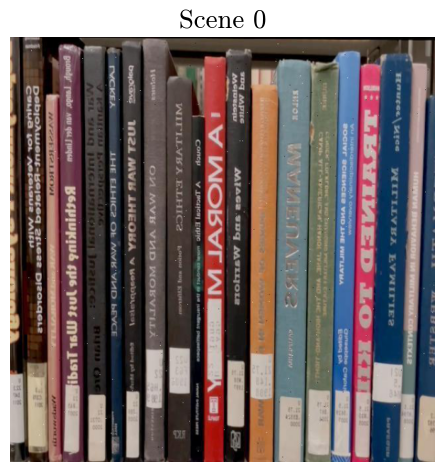

Processing scenes:   3%|▎         | 1/29 [00:01<00:44,  1.59s/it]

Scene 1: 2 books found, total area: 44632 pixels
  Individual areas: [23479, 21152] pixels


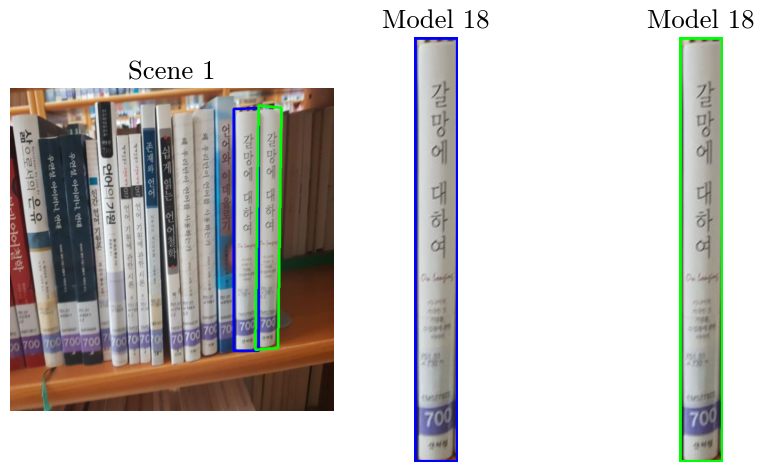

Processing scenes:   7%|▋         | 2/29 [00:03<00:42,  1.56s/it]

Scene 2: 1 books found, total area: 16408 pixels


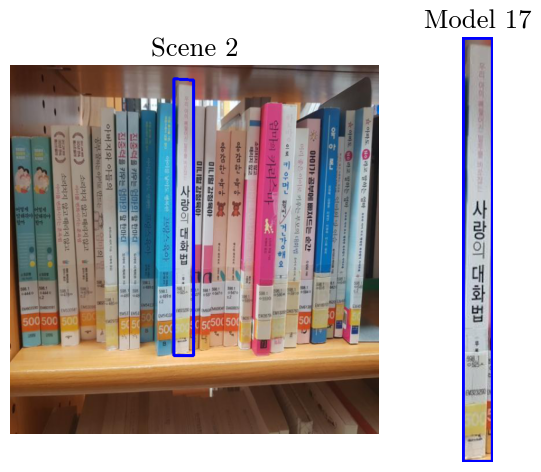

Processing scenes:  10%|█         | 3/29 [00:04<00:43,  1.66s/it]

Scene 3: 2 books found, total area: 30799 pixels
  Individual areas: [16195, 14605] pixels


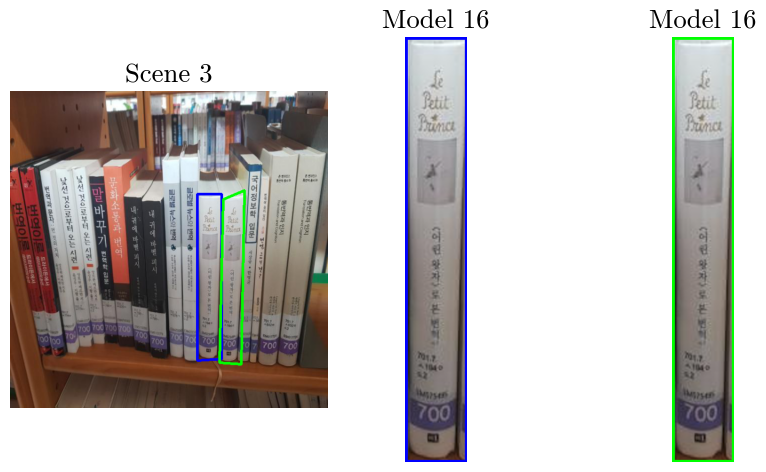

Processing scenes:  14%|█▍        | 4/29 [00:06<00:41,  1.65s/it]

Scene 4: 6 books found, total area: 152395 pixels
  Individual areas: [26719, 26772, 28306, 23302, 23569, 23728] pixels


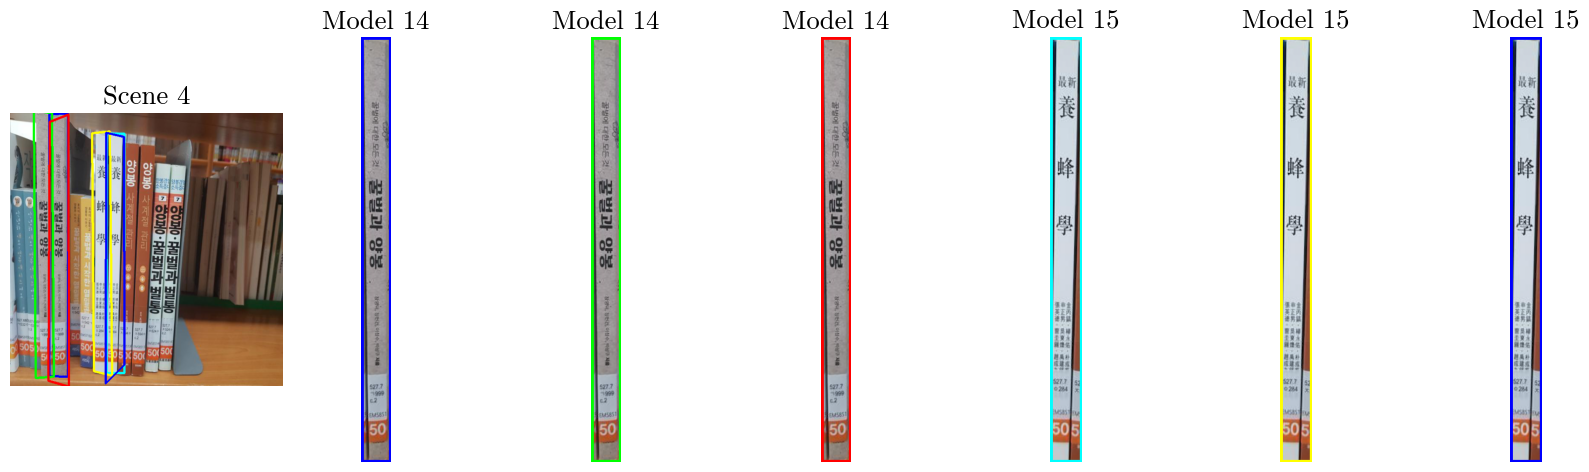

Processing scenes:  17%|█▋        | 5/29 [00:08<00:41,  1.75s/it]

Scene 5: 1 books found, total area: 21239 pixels


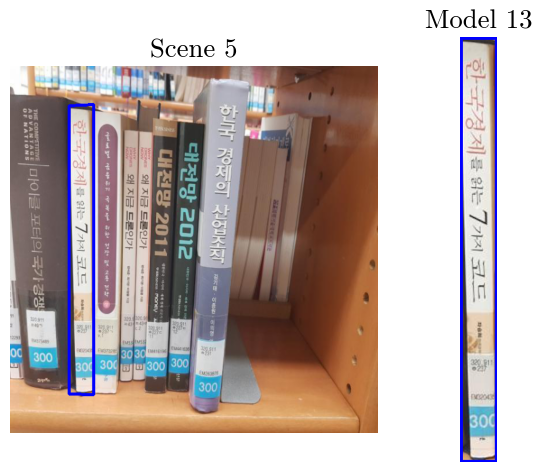

Processing scenes:  21%|██        | 6/29 [00:10<00:38,  1.69s/it]

Scene 6: 1 books found, total area: 26326 pixels


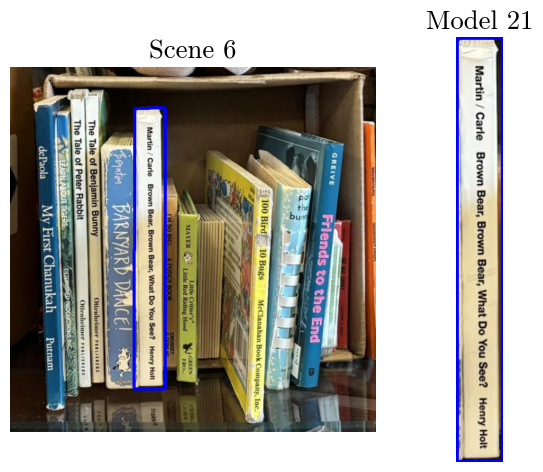

Processing scenes:  24%|██▍       | 7/29 [00:11<00:38,  1.76s/it]

Scene 7: 2 books found, total area: 41251 pixels
  Individual areas: [20665, 20586] pixels


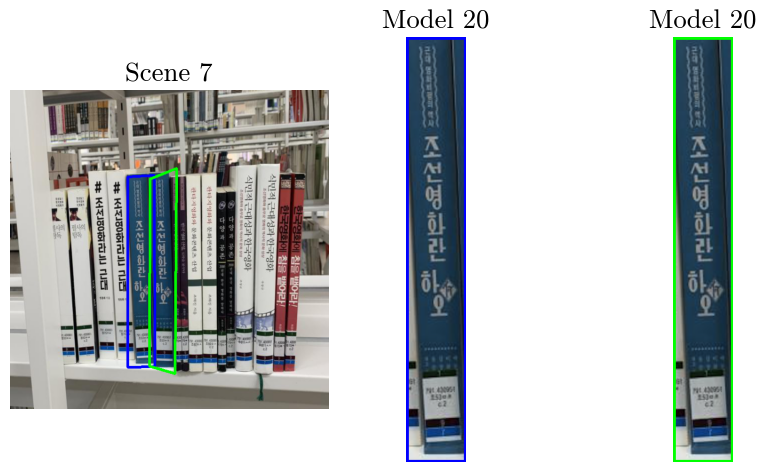

Processing scenes:  28%|██▊       | 8/29 [00:13<00:37,  1.77s/it]

Scene 8: No books found


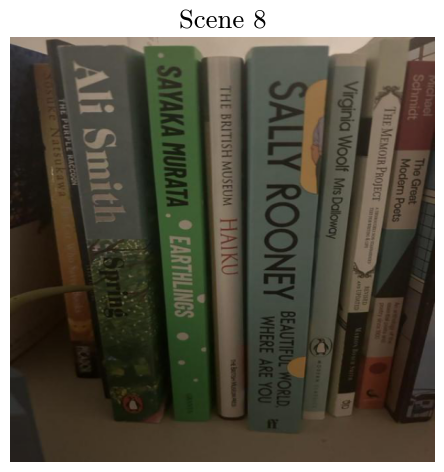

Processing scenes:  31%|███       | 9/29 [00:15<00:32,  1.64s/it]

Scene 9: 1 books found, total area: 8558 pixels


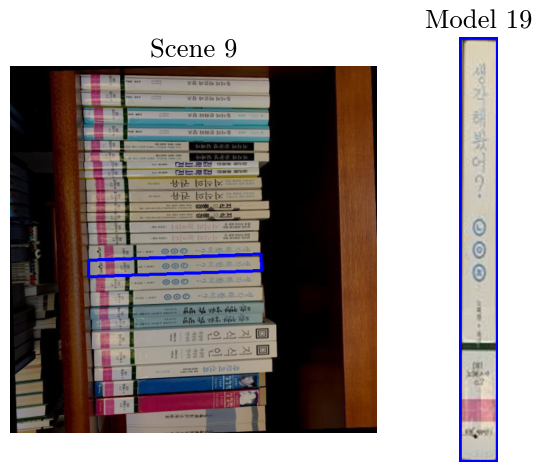

Processing scenes:  34%|███▍      | 10/29 [00:16<00:30,  1.61s/it]

Scene 10: 1 books found, total area: 8332 pixels


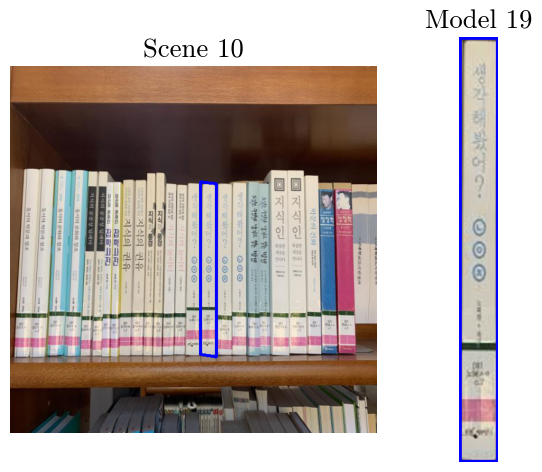

Processing scenes:  38%|███▊      | 11/29 [00:18<00:29,  1.62s/it]

Scene 11: No books found


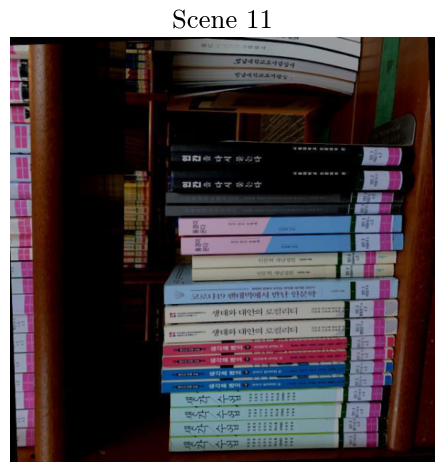

Processing scenes:  41%|████▏     | 12/29 [00:19<00:26,  1.58s/it]

Scene 12: No books found


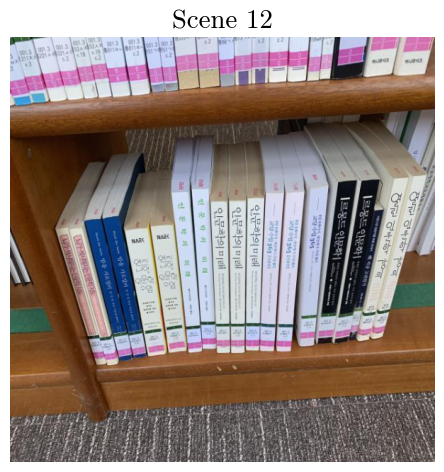

Processing scenes:  45%|████▍     | 13/29 [00:21<00:27,  1.74s/it]

Scene 13: No books found


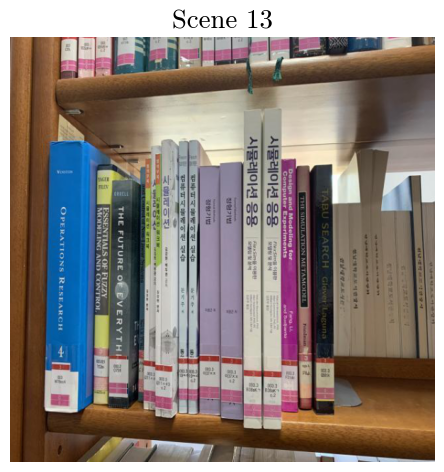

Processing scenes:  48%|████▊     | 14/29 [00:23<00:25,  1.68s/it]

Scene 14: No books found


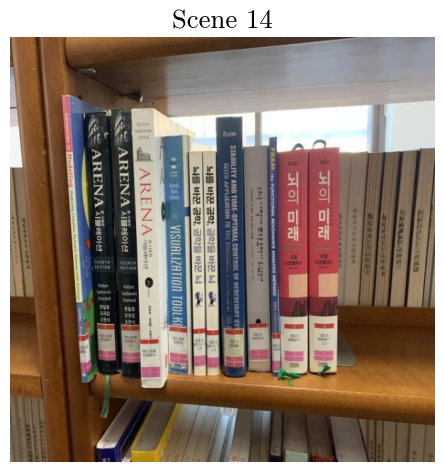

Processing scenes:  52%|█████▏    | 15/29 [00:24<00:22,  1.63s/it]

Scene 15: 2 books found, total area: 23642 pixels
  Individual areas: [14360, 9282] pixels


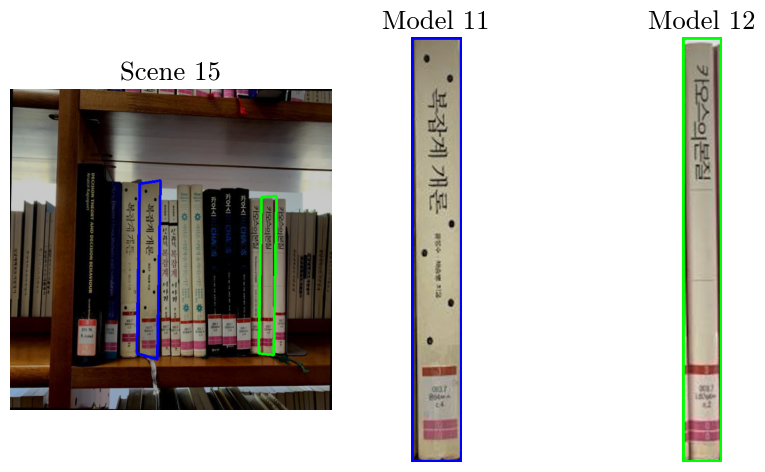

Processing scenes:  55%|█████▌    | 16/29 [00:26<00:20,  1.59s/it]

Scene 16: 3 books found, total area: 68374 pixels
  Individual areas: [13535, 9276, 45564] pixels


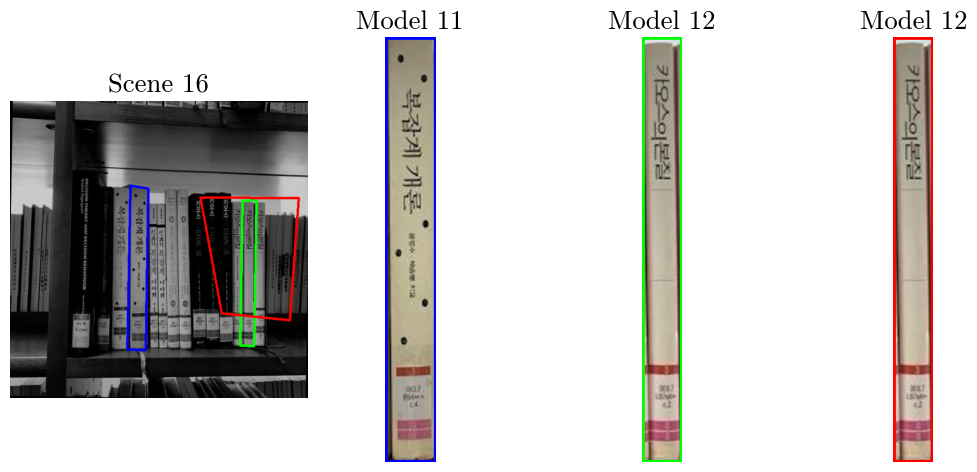

Processing scenes:  59%|█████▊    | 17/29 [00:27<00:19,  1.59s/it]

Scene 17: 2 books found, total area: 21961 pixels
  Individual areas: [13426, 8535] pixels


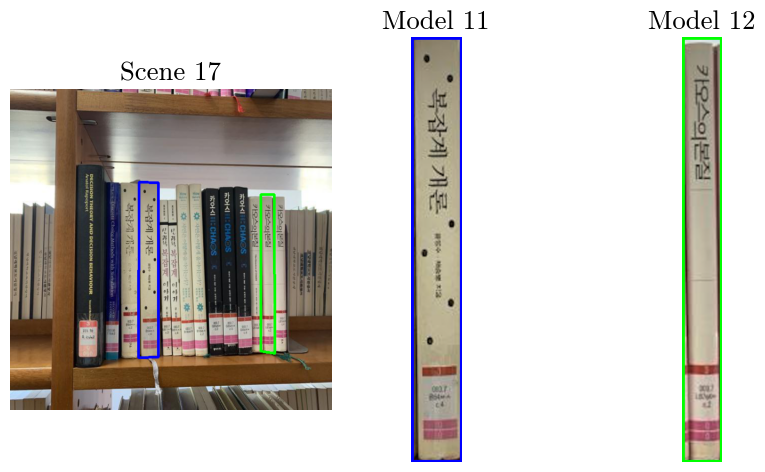

Processing scenes:  62%|██████▏   | 18/29 [00:29<00:17,  1.58s/it]

Scene 18: 7 books found, total area: 90177 pixels
  Individual areas: [12341, 10737, 11791, 10054, 14951, 16388, 13916] pixels


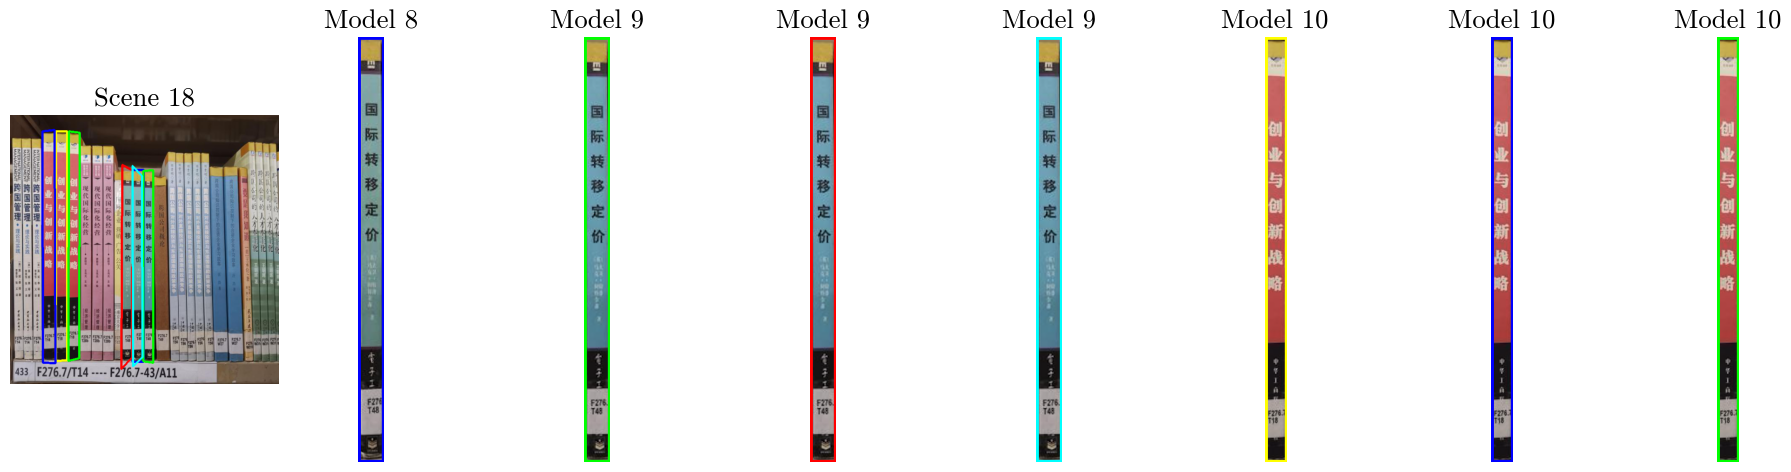

Processing scenes:  66%|██████▌   | 19/29 [00:32<00:18,  1.87s/it]

Scene 19: 3 books found, total area: 51258 pixels
  Individual areas: [12726, 20227, 18305] pixels


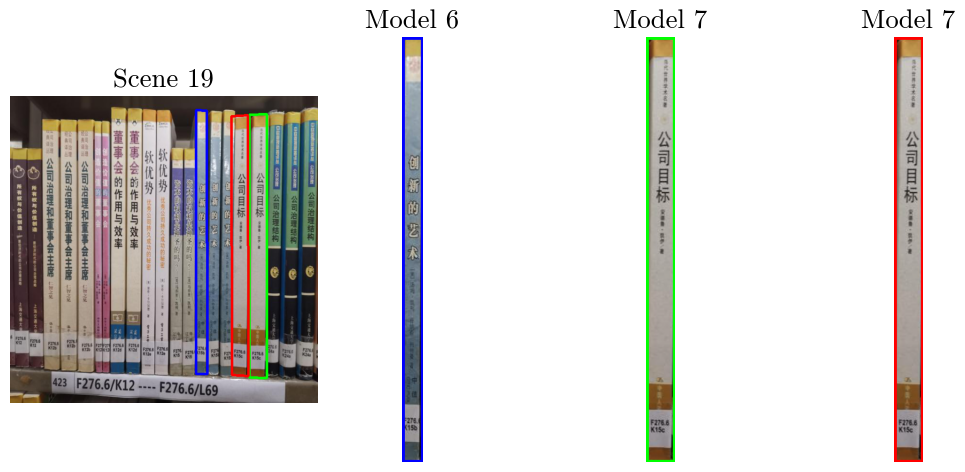

Processing scenes:  69%|██████▉   | 20/29 [00:34<00:17,  1.90s/it]

Scene 20: No books found


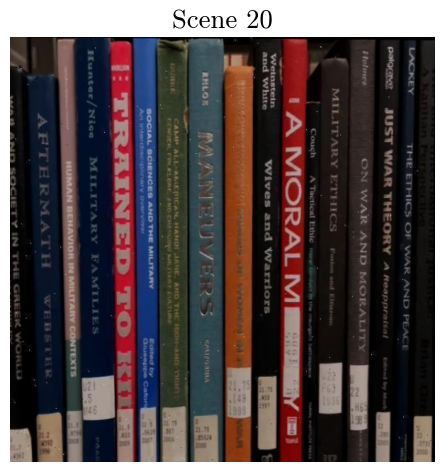

Processing scenes:  72%|███████▏  | 21/29 [00:35<00:14,  1.77s/it]

Scene 21: No books found


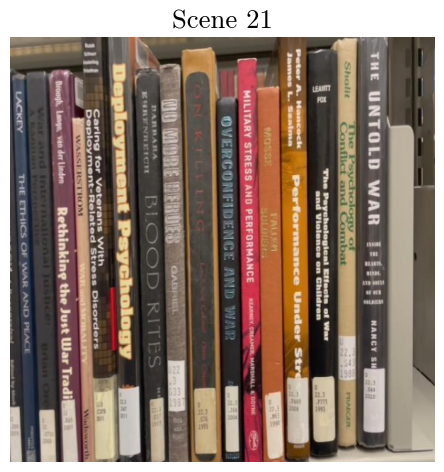

Processing scenes:  76%|███████▌  | 22/29 [00:37<00:12,  1.74s/it]

Scene 22: No books found


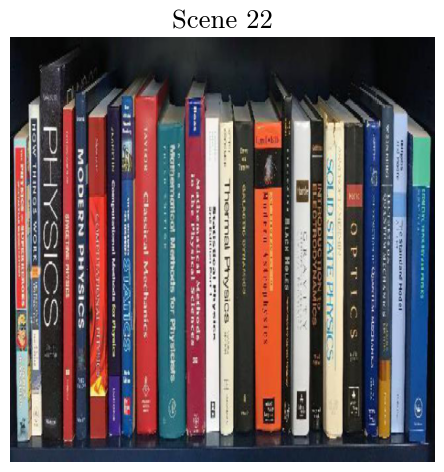

Processing scenes:  79%|███████▉  | 23/29 [00:39<00:10,  1.79s/it]

Scene 23: 1 books found, total area: 20768 pixels


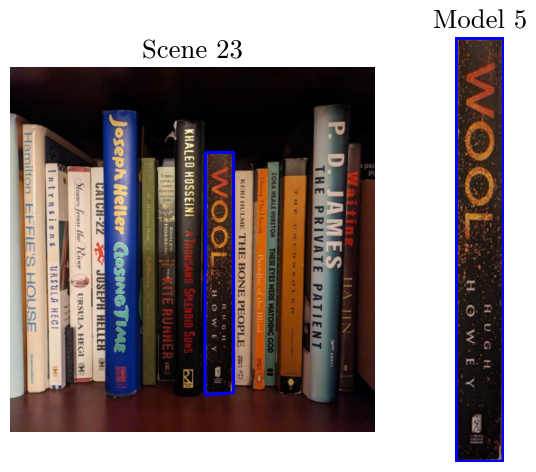

Processing scenes:  83%|████████▎ | 24/29 [00:40<00:08,  1.72s/it]

Scene 24: No books found


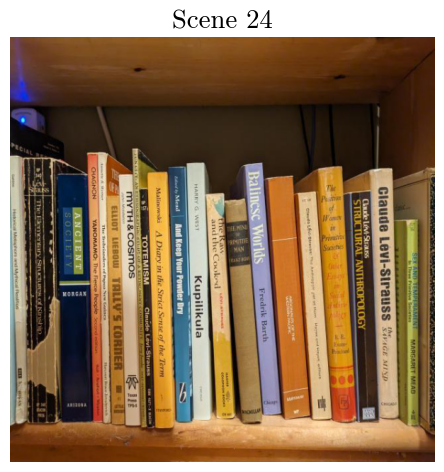

Processing scenes:  86%|████████▌ | 25/29 [00:42<00:06,  1.67s/it]

Scene 25: No books found


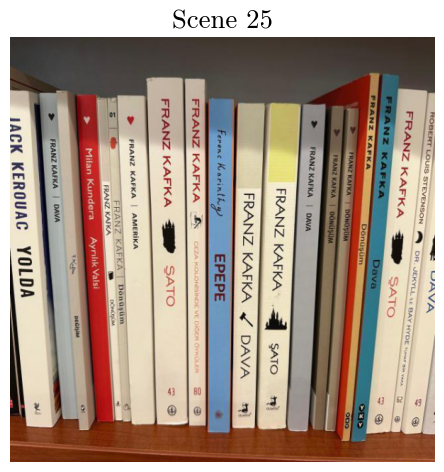

Processing scenes:  90%|████████▉ | 26/29 [00:43<00:04,  1.60s/it]

Scene 26: 4 books found, total area: 153210 pixels
  Individual areas: [13204, 13512, 63171, 63324] pixels


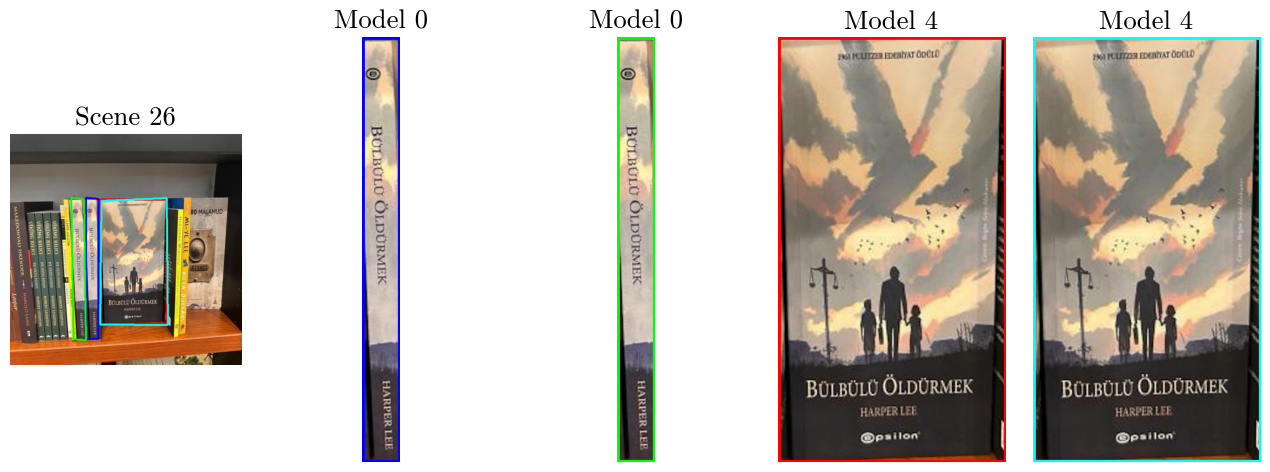

Processing scenes:  93%|█████████▎| 27/29 [00:45<00:03,  1.67s/it]

Scene 27: 3 books found, total area: 66778 pixels
  Individual areas: [18962, 26723, 21092] pixels


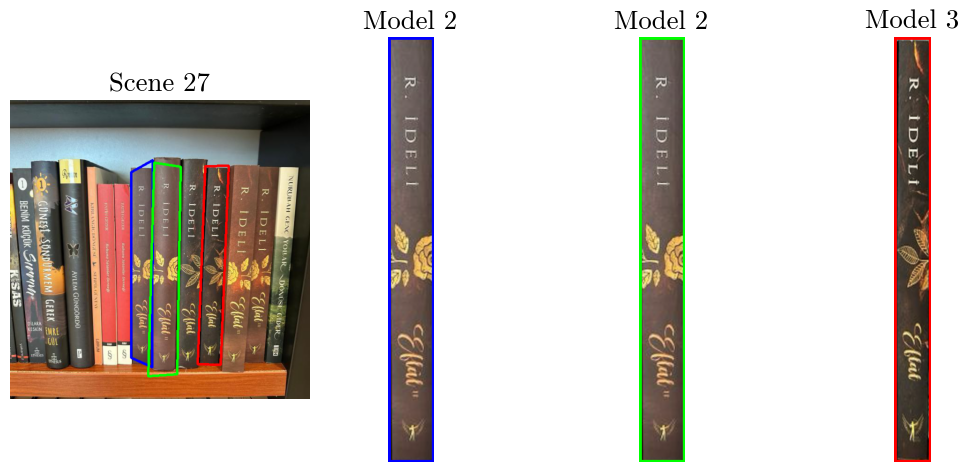

Processing scenes:  97%|█████████▋| 28/29 [00:47<00:01,  1.71s/it]

Scene 28: 2 books found, total area: 17336 pixels
  Individual areas: [8750, 8586] pixels


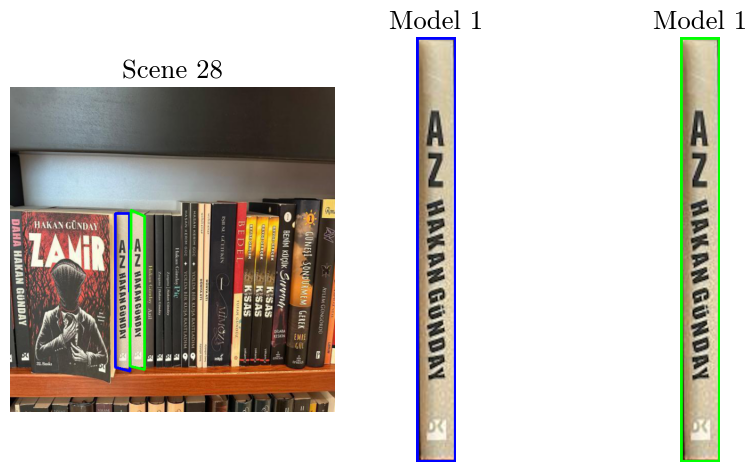

Processing scenes: 100%|██████████| 29/29 [00:49<00:00,  1.69s/it]


=== SUMMARY ===
Total area covered across all scenes: 863445 pixels


In [181]:
# Sostituisci la cella con il loop principale con questo codice:

def preprocess_for_sift(image):
    # 1. Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # 2. Denoising leggero
    denoised = cv2.GaussianBlur(gray, (3, 3), 0)
    
    # 3. Nessuna equalizzazione (i colori originali sono informativi)
    return denoised



DEBUG = False
total_area_all_scenes = 0

for SCENE_IDX in tqdm(range(len(scenes_images)), desc="Processing scenes"):
    scenes_image = scenes_images[SCENE_IDX].copy()

    
    
    scene_gray = preprocess_for_sift(scenes_image)

    # Estrai keypoints e descriptors della scena UNA SOLA VOLTA
    sift = cv2.SIFT_create(
        nfeatures=0,
        nOctaveLayers=5,
        contrastThreshold=0.015,
        edgeThreshold=25,
        sigma=1.6,
    )
    scene_keypoints, scene_descriptors = sift.detectAndCompute(scene_gray, None)
    
    # Lista degli indici dei keypoints ancora disponibili
    available_keypoint_indices = set(range(len(scene_keypoints)))

    matches = []
    
    for idx, m in enumerate(models_images):
        model_image = m.copy()

        # Preprocessing del modello
        model_gray = preprocess_for_sift(model_image)
        
        # Estrai keypoints e descriptors del modello
        model_keypoints, model_descriptors = sift.detectAndCompute(model_gray, None)

        for iteration in range(10):
            if len(available_keypoint_indices) < 3:
                if DEBUG:
                    print(f"Model {idx}: Not enough available keypoints in scene")
                break

            # Crea array di descriptors filtrati (solo quelli ancora disponibili)
            available_indices = sorted(available_keypoint_indices)
            filtered_scene_descriptors = scene_descriptors[available_indices]
            # Match descriptors usando BFMatcher
            bf = cv2.BFMatcher(cv2.NORM_L2)
            knn_matches = bf.knnMatch(model_descriptors, filtered_scene_descriptors, k=2)

            # Filter good matches con Lowe's ratio test
            good_matches = []
            for m, n in knn_matches:
                if m.distance < 0.9 * n.distance:
                    good_matches.append(m)

            if len(good_matches) < 3:
                if DEBUG:
                    print(f"Model {idx}, Iteration {iteration}: Not enough good matches")
                break

            # Converti gli indici dei match da indici filtrati a indici originali
            model_matching_keypoints = []
            scene_matching_keypoints = []
            matched_scene_indices = []
            
            for match in good_matches:
                # match.trainIdx si riferisce all'indice nel filtered_descriptors
                original_scene_idx = available_indices[match.trainIdx]
                
                model_matching_keypoints.append(model_keypoints[match.queryIdx].pt)
                scene_matching_keypoints.append(scene_keypoints[original_scene_idx].pt)
                matched_scene_indices.append(original_scene_idx)

            model_matching_keypoints = np.float32(model_matching_keypoints).reshape(-1, 1, 2)
            scene_matching_keypoints = np.float32(scene_matching_keypoints).reshape(-1, 1, 2)

            # Compute homography using RANSAC
            H, mask = cv2.findHomography(
                model_matching_keypoints, scene_matching_keypoints, cv2.RANSAC, 15.0
            )

            if H is None:
                if DEBUG:
                    print(f"Model {idx}, Iteration {iteration}: Homography could not be computed")
                break

            if DEBUG:
                inlier_mask = mask.ravel().tolist()
                num_inliers = sum(inlier_mask)
                print(f"Model {idx}, Iteration {iteration}: RANSAC inliers: {num_inliers} / {len(good_matches)}")

            # Get corners del modello
            model_corners = np.float32([
                [0, 0],
                [model_image.shape[1], 0],
                [model_image.shape[1], model_image.shape[0]],
                [0, model_image.shape[0]],
            ]).reshape(-1, 1, 2)

            # Transform corners usando homography
            scene_corners = cv2.perspectiveTransform(model_corners, H)

            # Valida il rettangolo
            is_valid, reason = is_rectangle_valid(scene_corners)
            
            if DEBUG:
                print(f"Model {idx}, Iteration {iteration}, Valid: {is_valid}, Reason: {reason}")

            if not is_valid:
                break

            # Aggiungi il match
            matches.append((model_image, scene_corners, idx))

            # RIMUOVI i keypoints matchati dagli inliers di RANSAC
            inlier_indices = []
            for i, is_inlier in enumerate(mask.ravel()):
                if is_inlier:
                    inlier_indices.append(matched_scene_indices[i])
            
            # Rimuovi gli indici dei keypoints usati come inliers
            available_keypoint_indices -= set(inlier_indices)
            
            if DEBUG:
                print(f"Model {idx}, Iteration {iteration}: Removed {len(inlier_indices)} keypoints, {len(available_keypoint_indices)} remaining")

    # Calcola e stampa info aree
    scene_total_area = print_area_info(matches, SCENE_IDX)
    total_area_all_scenes += scene_total_area

    # Mantieni la visualizzazione originale
    plot_detections(scenes_images, matches, SCENE_IDX=SCENE_IDX)

# Stampa statistiche finali
print(f"\n=== SUMMARY ===")
print(f"Total area covered across all scenes: {total_area_all_scenes:.0f} pixels")

In [182]:
""" def preprocess_for_sift(gray):
    # Produce an aggressive preprocessing to enhance SIFT performance
    # Apply Gaussian blur to reduce noise and improve keypoint detection
    blurred = cv2.GaussianBlur(gray, (13, 13), 0)
    # Apply histogram equalization to improve contrast
    equalized = cv2.equalizeHist(blurred)
    return equalized


DEBUG = False
total_area_all_scenes = 0  # Aggiungi contatore totale

for SCENE_IDX in tqdm(range(len(scenes_images)), desc="Processing scenes"):
    scenes_image = scenes_images[SCENE_IDX].copy()

    matches = []
    for idx, m in enumerate(models_images):
        model_image = m.copy()

        for i in range(10):
            

            scene_corners = instance_detect(
                scenes_image,
                model_image,
                preprocess=preprocess_for_sift,
                plot_matches=DEBUG,
                plot_rectangle=DEBUG,
                plot_descriptors=DEBUG,
                debug=DEBUG,
            )
            is_valid, reason = is_rectangle_valid(scene_corners)
            if DEBUG:
                print(
                    f"Model {idx}, Iteration {i}, Valid: {is_valid}, Reason: {reason}"
                )
            if not is_valid:
                break
            # Mask the detected area in the scene image to find another instance
            mask = np.zeros(scenes_image.shape[:2], dtype=np.uint8)

            matches.append((model_image, scene_corners, idx))
            cv2.fillPoly(mask, [np.int32(scene_corners)], (255))
            scenes_image = cv2.bitwise_and(
                scenes_image, scenes_image, mask=cv2.bitwise_not(mask)
            )

    # AGGIUNGI: Calcola e stampa info aree
    scene_total_area = print_area_info(matches, SCENE_IDX)
    total_area_all_scenes += scene_total_area

    # Mantieni la visualizzazione originale
    plot_detections(scenes_images, matches, SCENE_IDX=SCENE_IDX)

    # break  # Rimuovi o mantieni per testare una sola scena

# AGGIUNGI: Stampa statistiche finali
print(f"\n=== SUMMARY ===")
print(f"Total area covered across all scenes: {total_area_all_scenes:.0f} pixels") """

' def preprocess_for_sift(gray):\n    # Produce an aggressive preprocessing to enhance SIFT performance\n    # Apply Gaussian blur to reduce noise and improve keypoint detection\n    blurred = cv2.GaussianBlur(gray, (13, 13), 0)\n    # Apply histogram equalization to improve contrast\n    equalized = cv2.equalizeHist(blurred)\n    return equalized\n\n\nDEBUG = False\ntotal_area_all_scenes = 0  # Aggiungi contatore totale\n\nfor SCENE_IDX in tqdm(range(len(scenes_images)), desc="Processing scenes"):\n    scenes_image = scenes_images[SCENE_IDX].copy()\n\n    matches = []\n    for idx, m in enumerate(models_images):\n        model_image = m.copy()\n\n        for i in range(10):\n\n\n            scene_corners = instance_detect(\n                scenes_image,\n                model_image,\n                preprocess=preprocess_for_sift,\n                plot_matches=DEBUG,\n                plot_rectangle=DEBUG,\n                plot_descriptors=DEBUG,\n                debug=DEBUG,\n        

## Evaluation criteria

1. **Clarity and conciseness**. Present your work in a readable way: format your code and comment every important step;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach and justify every decision you make;

3. **Correctness of results**. Try to solve as many instances as possible. You should be able to solve all the instances of the assignment, however, a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.
